In [1]:
from google.colab import files
files.upload()  # upload your kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"emadshaker1999","key":"e75ca669f2035a7128dc7a194b201b5e"}'}

In [2]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Done!")

Done!


In [7]:
!kaggle datasets download -d espsiyam/nuclei-image-segmentation --unzip -p /content/cells

Dataset URL: https://www.kaggle.com/datasets/espsiyam/nuclei-image-segmentation
License(s): CC0-1.0
100% 89.4M/89.4M [00:05<00:00, 16.2MB/s]



In [8]:
import os

for item in os.listdir('/content/cells'):
    print(item)

U_NET


In [9]:
for item in os.listdir('/content/cells/U_NET'):
    print(item)

train
test


In [10]:
for item in os.listdir('/content/cells/U_NET/train'):
    print(item)

...


In [11]:
items = os.listdir('/content/cells/U_NET/train')
print(f"Total items: {len(items)}")
print("First item:", items[0])

# Look inside the first folder
first_folder = f'/content/cells/U_NET/train/{items[0]}'
print("\nContents:")
print(os.listdir(first_folder))

Total items: 669
First item: 091944f1d2611c916b98c020bd066667e33f4639159b2a92407fe5a40788856d

Contents:
['masks', 'images']


In [12]:
sample_folder = f'/content/cells/U_NET/train/{items[0]}'

images = os.listdir(f'{sample_folder}/images')
masks = os.listdir(f'{sample_folder}/masks')

print(f"Images: {images}")
print(f"Number of masks: {len(masks)}")
print(f"First few masks: {masks[:3]}")

Images: ['091944f1d2611c916b98c020bd066667e33f4639159b2a92407fe5a40788856d.png']
Number of masks: 44
First few masks: ['c043c1259f7f2032e98ea4c6d0d857872058c67b93e7a9c19d15cbeba798554d.png', '55bda680f11e851849e92c812eff475bc2ce2e13ec929def9b27094bc2f2f8f3.png', '50787e852763dcc15b892d62dda9dedffb7d879dcc7055fadc75a20e2ba055e6.png']


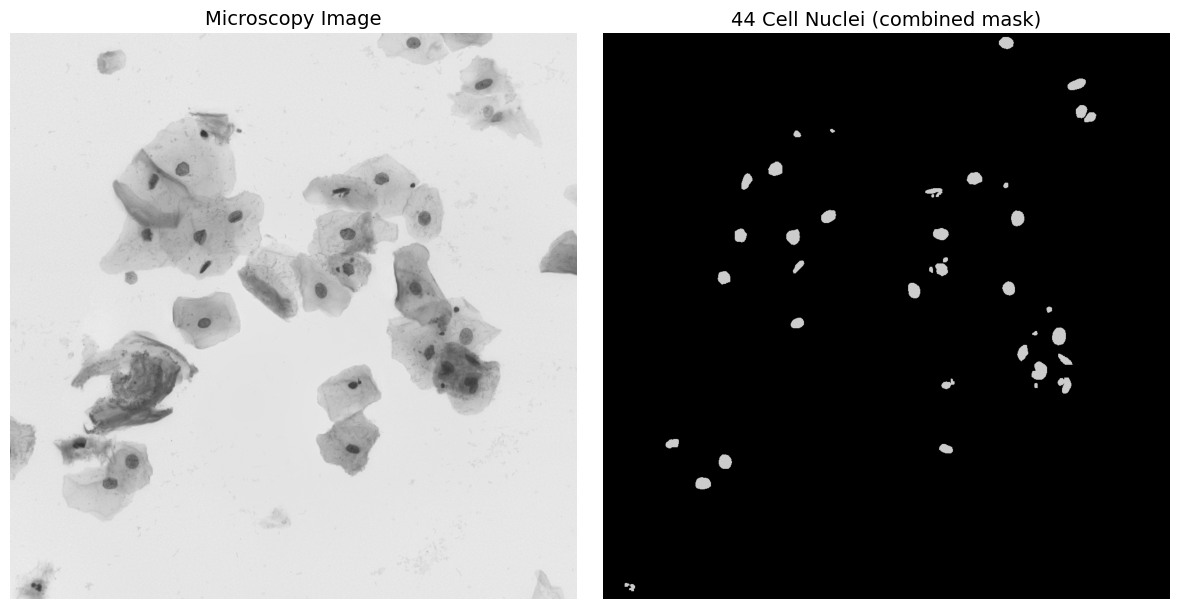

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load the main image
img = Image.open(f'{sample_folder}/images/{images[0]}')
img_array = np.array(img)

# Combine all masks into one
combined_mask = np.zeros(img_array.shape[:2])
for mask_file in masks:
    mask = np.array(Image.open(f'{sample_folder}/masks/{mask_file}'))
    combined_mask = np.maximum(combined_mask, mask)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_array)
axes[0].set_title('Microscopy Image', fontsize=14)
axes[1].imshow(combined_mask, cmap='nipy_spectral')
axes[1].set_title(f'{len(masks)} Cell Nuclei (combined mask)', fontsize=14)

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('cell_sample.png', dpi=150)
plt.show()

In [15]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

IMG_SIZE = 128

class CellDataset(Dataset):
    def __init__(self, folder_path, item_ids):
        self.folder_path = folder_path
        self.item_ids = item_ids

    def __len__(self):
        return len(self.item_ids)

    def __getitem__(self, idx):
        item_id = self.item_ids[idx]
        item_folder = f'{self.folder_path}/{item_id}'

        img_file = os.listdir(f'{item_folder}/images')[0]
        img = Image.open(f'{item_folder}/images/{img_file}').convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img = np.array(img) / 255.0

        mask_files = os.listdir(f'{item_folder}/masks')
        combined_mask = np.zeros((IMG_SIZE, IMG_SIZE))
        for mask_file in mask_files:
            mask = Image.open(f'{item_folder}/masks/{mask_file}').resize((IMG_SIZE, IMG_SIZE))
            mask = np.array(mask) > 0
            combined_mask = np.maximum(combined_mask, mask)

        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
        mask_tensor = torch.tensor(combined_mask, dtype=torch.float32).unsqueeze(0)

        return img_tensor, mask_tensor

from sklearn.model_selection import train_test_split
train_ids, test_ids = train_test_split(items, test_size=0.15, random_state=42)

train_dataset = CellDataset('/content/cells/U_NET/train', train_ids)
test_dataset = CellDataset('/content/cells/U_NET/train', test_ids)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")

Training images: 568
Test images: 101


In [18]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.1 MB/s eta 0:00:00


In [19]:
from monai.networks.nets import UNet
import torch.nn as nn

model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
).cuda()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Model ready!")

Model ready!


In [20]:
epochs = 20
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.cuda()
        Y_batch = Y_batch.cuda()

        pred = model(X_batch)
        loss = loss_fn(pred, Y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

print("\nTraining done! ✅")

Epoch 1/20 - Loss: 0.4706
Epoch 2/20 - Loss: 0.3281
Epoch 3/20 - Loss: 0.2619
Epoch 4/20 - Loss: 0.2203
Epoch 5/20 - Loss: 0.1919
Epoch 6/20 - Loss: 0.1709
Epoch 7/20 - Loss: 0.1558
Epoch 8/20 - Loss: 0.1424
Epoch 9/20 - Loss: 0.1321
Epoch 10/20 - Loss: 0.1224
Epoch 11/20 - Loss: 0.1153
Epoch 12/20 - Loss: 0.1111
Epoch 13/20 - Loss: 0.1070
Epoch 14/20 - Loss: 0.1014
Epoch 15/20 - Loss: 0.0966
Epoch 16/20 - Loss: 0.0933
Epoch 17/20 - Loss: 0.0935
Epoch 18/20 - Loss: 0.0935
Epoch 19/20 - Loss: 0.0862
Epoch 20/20 - Loss: 0.0821

Training done! ✅


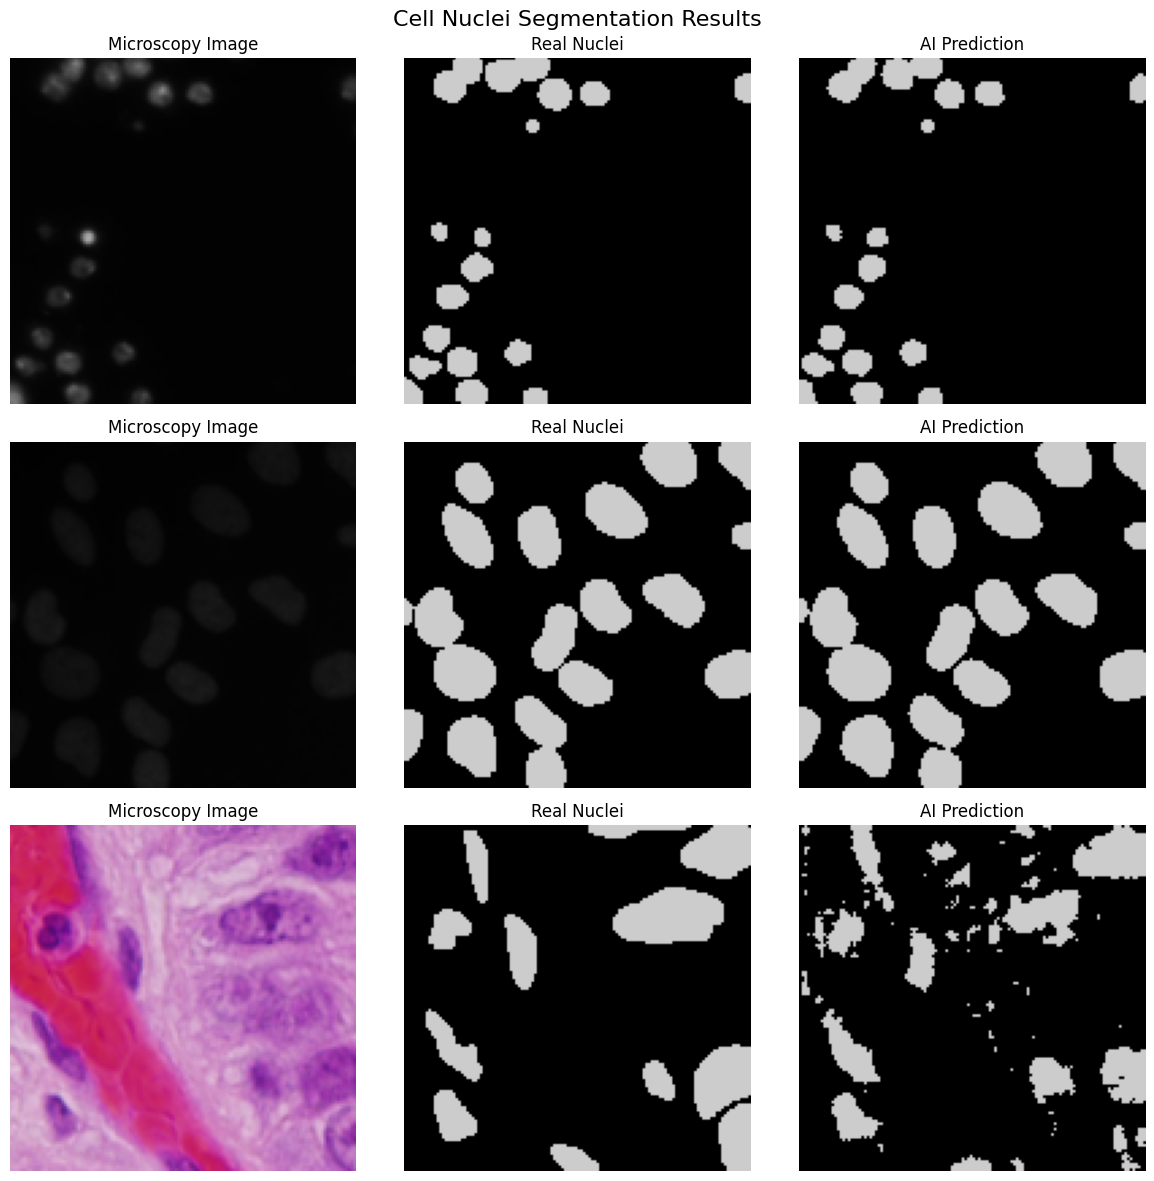

In [21]:
model.eval()
X_batch, Y_batch = next(iter(test_loader))

with torch.no_grad():
    pred = torch.sigmoid(model(X_batch.cuda())).cpu()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    img = X_batch[i].permute(1, 2, 0).numpy()
    true_mask = Y_batch[i, 0].numpy()
    pred_mask = (pred[i, 0].numpy() > 0.5)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Microscopy Image')

    axes[i, 1].imshow(true_mask, cmap='nipy_spectral')
    axes[i, 1].set_title('Real Nuclei')

    axes[i, 2].imshow(pred_mask, cmap='nipy_spectral')
    axes[i, 2].set_title('AI Prediction')

    for ax in axes[i]: ax.axis('off')

plt.suptitle('Cell Nuclei Segmentation Results', fontsize=16)
plt.tight_layout()
plt.savefig('cell_predictions.png', dpi=150)
plt.show()

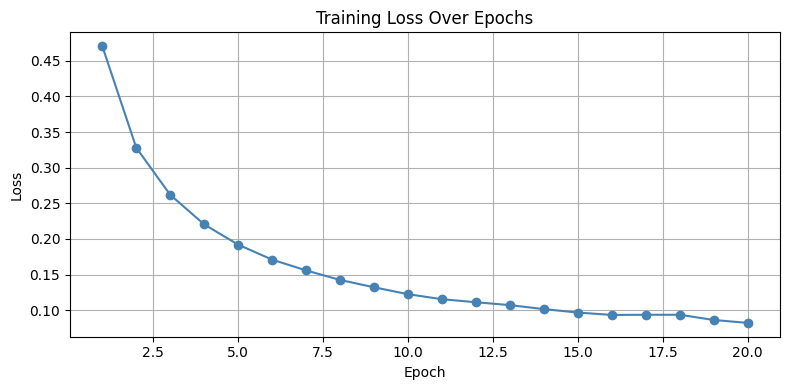

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='steelblue')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

In [23]:
from google.colab import files
files.download('cell_sample.png')
files.download('cell_predictions.png')
files.download('loss_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>